In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

ruta = "/home/jovyan/work/autotec/datos_etiquetados_kmeans_autotec"

df_clusters = spark.read.parquet(ruta)

print(df_clusters.count())

1988


In [2]:
df_clusters.printSchema()

root
 |-- precio: double (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- combustible_limpio: string (nullable = true)
 |-- marca_limpia: string (nullable = true)
 |-- modelo_limpio: string (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- cat_marca: integer (nullable = true)
 |-- cat_modelo: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: integer (nullable = true)



# Modelo Supervisado de Regresión - AutoTec

## Objetivo del modelo

El objetivo de este notebook es desarrollar un modelo supervisado de regresión para estimar el precio de vehículos usados, considerando como foco principal la depreciación asociada al kilometraje.

La variable dependiente será el precio del vehículo, ya que representa directamente el valor de mercado y permite analizar cómo factores como kilometraje, año, marca, modelo y segmento de depreciación influyen en la valorización del automóvil.

In [3]:
# ============================================
# 1. CONFIGURACIÓN INICIAL
# ============================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder \
    .appName("Supervisado_Regresion_AutoTec_Dani") \
    .getOrCreate()

print("Spark iniciado correctamente")

Spark iniciado correctamente


In [4]:
# ============================================
# 2. CARGA DEL DATASET FINAL
# ============================================

ruta_datos = "/home/jovyan/work/autotec/datos_etiquetados_kmeans_autotec"

df = spark.read.parquet(ruta_datos)

print("Dataset cargado correctamente")
print("Cantidad de registros:", df.count())

df.printSchema()

Dataset cargado correctamente
Cantidad de registros: 1988
root
 |-- precio: double (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- combustible_limpio: string (nullable = true)
 |-- marca_limpia: string (nullable = true)
 |-- modelo_limpio: string (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- cat_marca: integer (nullable = true)
 |-- cat_modelo: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: integer (nullable = true)



In [5]:
# ============================================
# 3. SELECCIÓN DE VARIABLE DEPENDIENTE Y VARIABLES EXPLICATIVAS
# ============================================

# Variable dependiente
variable_y = "precio"

# Variables explicativas seleccionadas
variables_x = [
    "kilometraje",
    "anio",
    "cat_marca",
    "cat_modelo",
    "prediction"
]

df_supervisado = df.select(
    variable_y,
    *variables_x
).dropna()

print("Registros disponibles para modelamiento:", df_supervisado.count())

df_supervisado.show(10)

Registros disponibles para modelamiento: 1988
+-------+-----------+----+---------+----------+----------+
| precio|kilometraje|anio|cat_marca|cat_modelo|prediction|
+-------+-----------+----+---------+----------+----------+
|2.199E7|    27294.0|2024|       14|       163|         3|
|1.899E7|    84917.0|2018|       14|       296|         1|
|1.589E7|    93687.0|2018|       14|       295|         1|
|2.199E7|    11766.0|2024|       14|       163|         3|
|1.297E7|   182000.0|2015|       14|       300|         1|
|5.599E7|    70030.0|2023|       14|       590|         2|
|5.199E7|    11824.0|2024|       14|       633|         2|
|1.495E7|    98188.0|2016|       12|       245|         1|
|2.997E7|    43000.0|2018|       12|       769|         0|
|5.997E7|    51500.0|2023|       12|       773|         2|
+-------+-----------+----+---------+----------+----------+
only showing top 10 rows



## Justificación de variables seleccionadas

Para el modelo supervisado se definió como variable dependiente el **precio**, debido a que representa el valor de mercado del vehículo usado y permite medir de forma indirecta la depreciación.

Las variables explicativas fueron seleccionadas porque se relacionan directamente con la pérdida de valor comercial:

- **Kilometraje:** es la variable central del proyecto, ya que representa el nivel de uso acumulado del vehículo.
- **Año:** permite controlar la antigüedad del automóvil.
- **Marca:** captura diferencias de posicionamiento comercial entre fabricantes.
- **Modelo:** permite distinguir vehículos dentro de una misma marca.
- **Prediction:** corresponde al clúster obtenido en el análisis no supervisado, incorporando al modelo supervisado los segmentos de depreciación previamente identificados.

Esta selección permite mantener coherencia entre el análisis exploratorio, el clustering y la etapa predictiva.

In [6]:
# ============================================
# 4. ESTADÍSTICAS DESCRIPTIVAS DEL DATASET SUPERVISADO
# ============================================

df_supervisado.describe().show()

+-------+--------------------+-----------------+------------------+------------------+------------------+------------------+
|summary|              precio|      kilometraje|              anio|         cat_marca|        cat_modelo|        prediction|
+-------+--------------------+-----------------+------------------+------------------+------------------+------------------+
|  count|                1988|             1988|              1988|              1988|              1988|              1988|
|   mean|1.6450598581488933E7|71069.67505030181|2021.3229376257545| 11.48943661971831|  188.023138832998|1.9280684104627765|
| stddev|   9970242.365990575| 49936.5845699762| 3.551382418604898|12.023772338271533|223.32775877341987|1.2333876048276222|
|    min|           2055000.0|           1000.0|              1991|                 0|                 0|                 0|
|    max|            1.0499E8|         300000.0|              2026|                64|               786|                 3|


In [7]:
# ============================================
# 5. VECTOR DE CARACTERÍSTICAS
# ============================================

assembler = VectorAssembler(
    inputCols=variables_x,
    outputCol="features_supervisado"
)

df_modelo = assembler.transform(df_supervisado)

df_modelo.select("precio", "features_supervisado").show(5, truncate=False)

+-------+--------------------------------+
|precio |features_supervisado            |
+-------+--------------------------------+
|2.199E7|[27294.0,2024.0,14.0,163.0,3.0] |
|1.899E7|[84917.0,2018.0,14.0,296.0,1.0] |
|1.589E7|[93687.0,2018.0,14.0,295.0,1.0] |
|2.199E7|[11766.0,2024.0,14.0,163.0,3.0] |
|1.297E7|[182000.0,2015.0,14.0,300.0,1.0]|
+-------+--------------------------------+
only showing top 5 rows



In [8]:
# ============================================
# 6. DIVISIÓN TRAIN / TEST
# ============================================

train_data, test_data = df_modelo.randomSplit([0.8, 0.2], seed=42)

print("Registros de entrenamiento:", train_data.count())
print("Registros de prueba:", test_data.count())

Registros de entrenamiento: 1633
Registros de prueba: 355


# Entrenamiento y Evaluación de Modelos

En esta etapa se entrenarán distintos modelos de regresión con el objetivo de estimar el precio de vehículos usados y evaluar qué tan bien representan la depreciación asociada al kilometraje.

Se compararán tres enfoques:

- Regresión Lineal
- Árbol de Decisión
- Random Forest

Las métricas utilizadas serán:

- R²
- RMSE
- MAE

In [10]:
# ============================================
# 7. ENTRENAMIENTO DE MODELOS
# ============================================

from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor
)

lr = LinearRegression(
    featuresCol="features_supervisado",
    labelCol="precio",
    predictionCol="pred_lr"
)

dt = DecisionTreeRegressor(
    featuresCol="features_supervisado",
    labelCol="precio",
    predictionCol="pred_dt",
    maxDepth=8
)

rf = RandomForestRegressor(
    featuresCol="features_supervisado",
    labelCol="precio",
    predictionCol="pred_rf",
    numTrees=100,
    maxDepth=10,
    seed=42
)

print("Entrenando Regresión Lineal...")
modelo_lr = lr.fit(train_data)

print("Entrenando Árbol de Decisión...")
modelo_dt = dt.fit(train_data)

print("Entrenando Random Forest...")
modelo_rf = rf.fit(train_data)

print("Modelos entrenados correctamente")

Entrenando Regresión Lineal...
Entrenando Árbol de Decisión...
Entrenando Random Forest...
Modelos entrenados correctamente


In [11]:
# ============================================
# 8. PREDICCIONES
# ============================================

pred_lr = modelo_lr.transform(test_data)
pred_dt = modelo_dt.transform(test_data)
pred_rf = modelo_rf.transform(test_data)

In [12]:
# ============================================
# 9. EVALUACIÓN DE MODELOS
# ============================================

from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

def evaluar(df_pred, columna_prediccion):

    r2 = RegressionEvaluator(
        labelCol="precio",
        predictionCol=columna_prediccion,
        metricName="r2"
    ).evaluate(df_pred)

    rmse = RegressionEvaluator(
        labelCol="precio",
        predictionCol=columna_prediccion,
        metricName="rmse"
    ).evaluate(df_pred)

    mae = RegressionEvaluator(
        labelCol="precio",
        predictionCol=columna_prediccion,
        metricName="mae"
    ).evaluate(df_pred)

    return r2, rmse, mae


resultados = []

for nombre, pred, columna in [
    ("Regresión Lineal", pred_lr, "pred_lr"),
    ("Árbol de Decisión", pred_dt, "pred_dt"),
    ("Random Forest", pred_rf, "pred_rf")
]:

    r2, rmse, mae = evaluar(pred, columna)

    resultados.append([
        nombre,
        round(r2, 3),
        round(rmse, 0),
        round(mae, 0)
    ])

tabla_resultados = pd.DataFrame(
    resultados,
    columns=["Modelo", "R2", "RMSE", "MAE"]
)

tabla_resultados

,Modelo,R2,RMSE,MAE
0,Regresión Lineal,0.105,10087410.0,6845462.0
1,Árbol de Decisión,0.534,7278513.0,4456136.0
2,Random Forest,0.728,5559016.0,3860461.0


## Interpretación de resultados

Los resultados muestran diferencias importantes entre los modelos evaluados.

La Regresión Lineal obtuvo un coeficiente de determinación bajo (R² = 0,105), indicando que la depreciación vehicular no sigue una relación estrictamente lineal entre kilometraje y precio.

El Árbol de Decisión mejoró considerablemente la capacidad explicativa (R² = 0,534), capturando relaciones no lineales entre las variables.

Finalmente, Random Forest obtuvo el mejor desempeño con un R² = 0,728, explicando aproximadamente el 72,8% de la variabilidad del precio de los vehículos.

Este resultado confirma que la depreciación depende simultáneamente del kilometraje, la antigüedad, la marca, el modelo y el segmento de mercado identificado previamente mediante K-Means.

Por esta razón, Random Forest se selecciona como modelo final.

# Análisis del desempeño del modelo

Se desarrollaron tres modelos supervisados de regresión con el objetivo de estimar el precio de vehículos usados y analizar el comportamiento de la depreciación asociada al kilometraje.

Los modelos evaluados fueron Regresión Lineal, Árbol de Decisión y Random Forest.

La Regresión Lineal obtuvo un coeficiente de determinación R² = 0,105, evidenciando que la depreciación del precio no puede explicarse mediante relaciones estrictamente lineales.

El Árbol de Decisión alcanzó R² = 0,534, mostrando una mejora importante al capturar comportamientos no lineales presentes en el mercado automotriz.

El mejor resultado fue obtenido por Random Forest con R² = 0,728, permitiendo explicar aproximadamente el 72,8% de la variación del precio.

Estos resultados demuestran que la depreciación vehicular no depende únicamente del kilometraje, sino también de variables estructurales como:

- Antigüedad del vehículo.
- Marca.
- Modelo.
- Segmentación comercial obtenida mediante clustering.

La incorporación del clúster generado mediante K-Means permitió transferir conocimiento del análisis no supervisado hacia el modelo predictivo, mejorando la capacidad explicativa.

Por lo tanto, Random Forest se selecciona como modelo final debido a su mayor precisión y menor error de estimación.

# Visualización del Modelo Seleccionado

Para interpretar visualmente el desempeño del modelo final se comparará el precio real versus el precio estimado mediante Random Forest.

Esta visualización permite evaluar el comportamiento del modelo respecto a la depreciación vehicular.

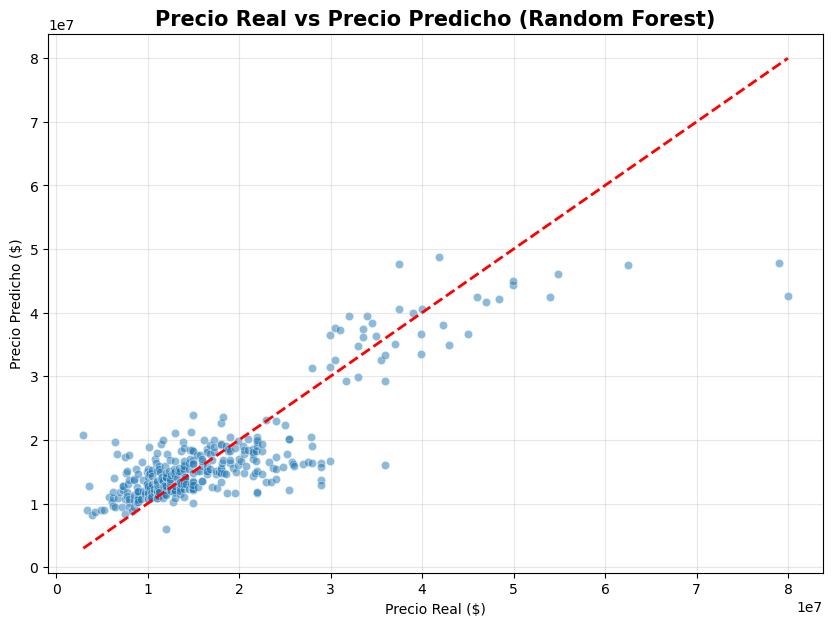

In [13]:
# ============================================
# 10. VISUALIZACIÓN RANDOM FOREST
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convertir solo columnas necesarias
grafico = pred_rf.select(
    "precio",
    "pred_rf"
).toPandas()

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=grafico,
    x="precio",
    y="pred_rf",
    alpha=0.5
)

plt.plot(
    [grafico["precio"].min(), grafico["precio"].max()],
    [grafico["precio"].min(), grafico["precio"].max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Precio Real vs Precio Predicho (Random Forest)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Precio Real ($)")
plt.ylabel("Precio Predicho ($)")

plt.grid(alpha=0.3)

plt.show()

# Conclusiones del Modelo Supervisado

Los resultados obtenidos permiten concluir que el precio de los vehículos usados puede ser estimado con un nivel alto de precisión utilizando técnicas de aprendizaje supervisado.

El modelo Random Forest obtuvo el mejor desempeño alcanzando un coeficiente de determinación R² = 0,728.

Esto indica que aproximadamente el 72,8% del comportamiento del precio puede ser explicado mediante las variables utilizadas.

El análisis demuestra que el kilometraje constituye uno de los factores más relevantes en la depreciación; sin embargo, no actúa de forma aislada.

La antigüedad del vehículo, la marca, el modelo y el segmento identificado mediante K-Means generan efectos complementarios sobre el valor final.

Como trabajo futuro se propone incorporar variables adicionales como región, transmisión y características del vehículo para aumentar aún más la capacidad predictiva.

/tmp/ipykernel_1363/1508124424.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


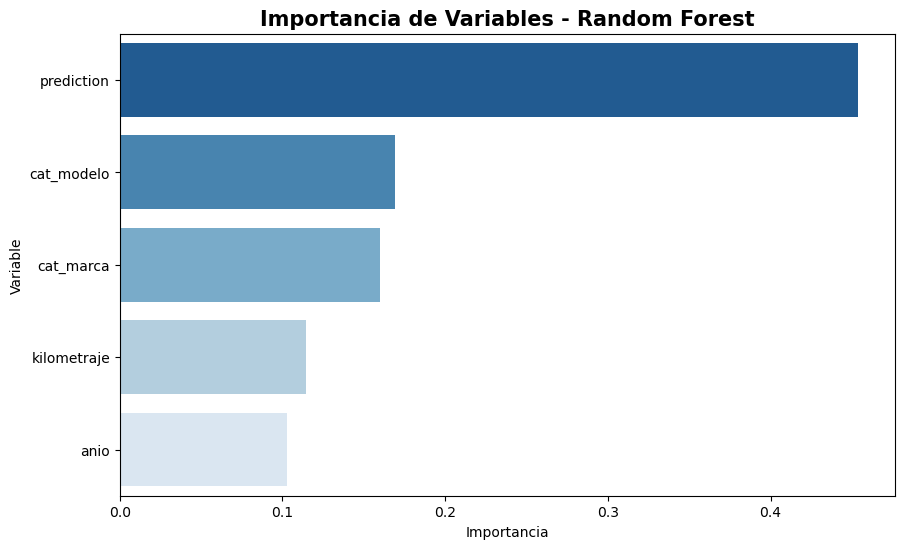

,Variable,Importancia
4,prediction,0.453662
3,cat_modelo,0.168928
2,cat_marca,0.160145
0,kilometraje,0.114689
1,anio,0.102575


In [15]:
# ============================================
# 11. IMPORTANCIA VARIABLES
# ============================================

import pandas as pd

imp = pd.DataFrame({
    "Variable": variables_x,
    "Importancia": modelo_rf.featureImportances.toArray()
})

imp = imp.sort_values(
    by="Importancia",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=imp,
    x="Importancia",
    y="Variable",
    palette="Blues_r"
)

plt.title(
    "Importancia de Variables - Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.show()

imp

In [16]:
# ============================================
# COMPARACIÓN DE MODELOS
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=resultado,
    x="Modelo",
    y="R2",
    palette="Blues"
)

plt.axhline(
    0.70,
    color="red",
    linestyle="--",
    label="Objetivo 70%"
)

plt.title(
    "Comparación de desempeño entre modelos",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Coeficiente R²")

plt.legend()

plt.show()

NameError: name 'resultado' is not defined

<Figure size 1000x600 with 0 Axes>